In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

In [2]:
data = pd.read_csv("../Dataset/loan_prediction.csv")

In [3]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [5]:
data.shape

(614, 13)

In [6]:
data['Gender'] = data['Gender'].map({'Female':1,'Male':0})


In [7]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [8]:
data['Property_Area'] = data['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})

data['Married'] = data['Married'].map({'Yes':1,'No':0})

data['Education'] = data['Education'].map({'Graduate':1,'Not Graduate':0})

data['Loan_Status'] = data['Loan_Status'].map({'Y':1,'N':0})

data['Self_Employed'] = data['Self_Employed'].map({'Yes':1,'No':0})

In [9]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [10]:
# Handling missing values

data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Dependents'] = data['Dependents'].str.replace('+', '', regex=False)
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['LoanAmount'] = data['LoanAmount'].fillna(data['LoanAmount'].mean())
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [33]:
# Changing the data type of each column

data['Gender'] = data['Gender'].astype('int64')
data['Married'] = data['Married'].astype('int64')
data['Dependents'] = data['Dependents'].astype('int64')
data['Self_Employed'] = data['Self_Employed'].astype('int64')
data['CoapplicantIncome'] = data['CoapplicantIncome'].astype('int64')
data['LoanAmount'] = data['LoanAmount'].astype('int64')
data['Loan_Amount_Term'] = data['Loan_Amount_Term'].astype('int64')
data['Credit_History'] = data['Credit_History'].astype('int64')

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Loan_ID            614 non-null    str  
 1   Gender             614 non-null    int64
 2   Married            614 non-null    int64
 3   Dependents         614 non-null    int64
 4   Education          614 non-null    int64
 5   Self_Employed      614 non-null    int64
 6   ApplicantIncome    614 non-null    int64
 7   CoapplicantIncome  614 non-null    int64
 8   LoanAmount         614 non-null    int64
 9   Loan_Amount_Term   614 non-null    int64
 10  Credit_History     614 non-null    int64
 11  Property_Area      614 non-null    int64
 12  Loan_Status        614 non-null    int64
dtypes: int64(12), str(1)
memory usage: 62.5 KB


In [11]:
# Splitting features and target variable

X = data.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = data['Loan_Status']

X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.0,0.0,0,1,0.0,5849,0.0,146.412162,360.0,1.0,2
1,0.0,1.0,1,1,0.0,4583,1508.0,128.000000,360.0,1.0,0
2,0.0,1.0,0,1,1.0,3000,0.0,66.000000,360.0,1.0,2
3,0.0,1.0,0,0,0.0,2583,2358.0,120.000000,360.0,1.0,2
4,0.0,0.0,0,1,0.0,6000,0.0,141.000000,360.0,1.0,2


In [12]:
# Checking feature and target shapes

print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [13]:
data.describe()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.182410,0.653094,0.781759,0.133550,5403.459283,1621.245798,146.412162,342.410423,0.855049,1.037459,0.687296
std,0.386497,0.476373,0.413389,0.340446,6109.041673,2926.248369,84.037468,64.428629,0.352339,0.787482,0.463973
min,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,0.000000,3812.500000,1188.500000,129.000000,360.000000,1.000000,1.000000,1.000000
75%,0.000000,1.000000,1.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000


In [14]:
# Scaling the features

from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

X_bal = sc.fit_transform(X)

X_bal = pd.DataFrame(X_bal, columns=X.columns)

X_bal.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,-0.472343,-1.372089,-0.737806,0.528362,-0.392601,0.072991,-0.554487,0.000000,0.273231,0.411733,1.223298
1,-0.472343,0.728816,0.253470,0.528362,-0.392601,-0.134412,-0.038732,-0.219273,0.273231,0.411733,-1.318513
2,-0.472343,0.728816,-0.737806,0.528362,2.547117,-0.393747,-0.554487,-0.957641,0.273231,0.411733,1.223298
3,-0.472343,0.728816,-0.737806,-1.892641,-0.392601,-0.462062,0.251980,-0.314547,0.273231,0.411733,1.223298
4,-0.472343,-1.372089,-0.737806,0.528362,-0.392601,0.097728,-0.554487,-0.064454,0.273231,0.411733,1.223298


In [15]:
# Splitting the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_bal,
    y,
    test_size=0.33,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(411, 11)
(203, 11)
(411,)
(203,)


In [16]:
# Building the Decision Tree model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 1.0
Testing Accuracy  : 0.6650246305418719


In [17]:
# Building the Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 1.0
Testing Accuracy  : 0.7832512315270936


In [18]:
# Building the KNN model

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

train_pred = knn.predict(X_train)
test_pred = knn.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 0.8272506082725061
Testing Accuracy  : 0.7733990147783252


In [19]:
# Building the Gradient Boosting model

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

train_pred = gb.predict(X_train)
test_pred = gb.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 0.9099756690997567
Testing Accuracy  : 0.7684729064039408


In [20]:
# Checking Gradient Boosting accuracy

train_pred = gb.predict(X_train)
test_pred = gb.predict(X_test)

print("Training Accuracy :", accuracy_score(y_train, train_pred))
print("Testing Accuracy  :", accuracy_score(y_test, test_pred))

Training Accuracy : 0.9099756690997567
Testing Accuracy  : 0.7684729064039408


In [21]:
# Saving the Random Forest model

import pickle

pickle.dump(rf, open('rdf.pkl', 'wb'))

In [22]:
# Saving the StandardScaler

pickle.dump(sc, open('scale1.pkl', 'wb'))

In [23]:
# Saving the Random Forest model

import pickle

pickle.dump(rf, open('rdf.pkl', 'wb'))

In [24]:
# Saving the Standard Scaler

pickle.dump(sc, open('scale1.pkl', 'wb'))

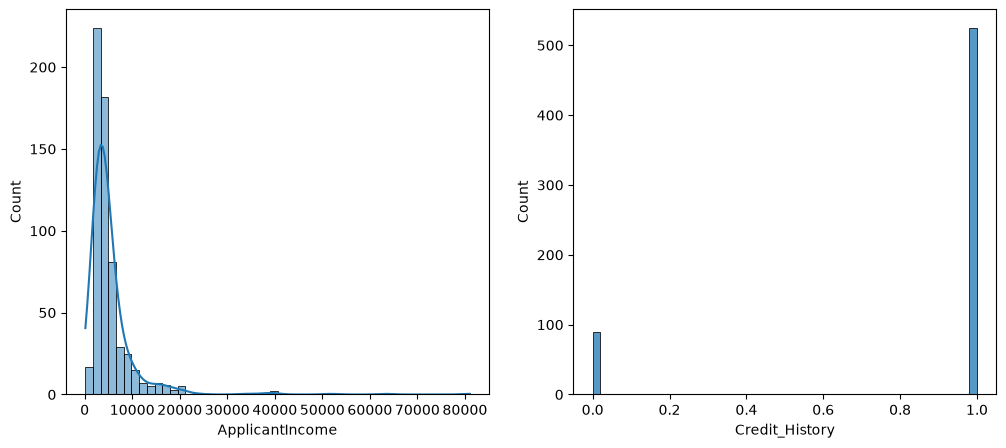

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(121)
sns.histplot(data["ApplicantIncome"], kde=True)

plt.subplot(122)
sns.histplot(data["Credit_History"])

plt.show()

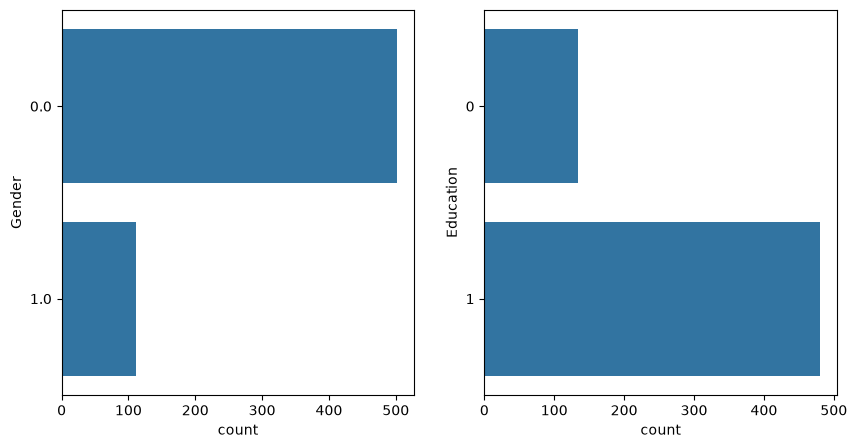

In [26]:
plt.figure(figsize=(10,5))

plt.subplot(121)
sns.countplot(y=data["Gender"])

plt.subplot(122)
sns.countplot(y=data["Education"])

plt.show()

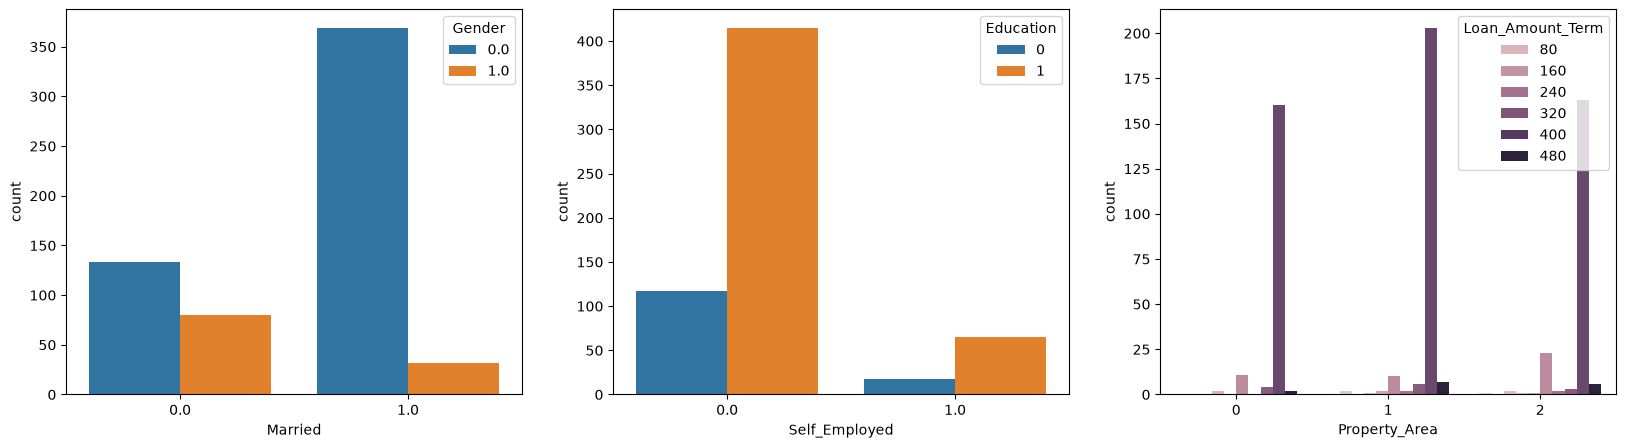

In [27]:
plt.figure(figsize=(20,5))

plt.subplot(131)
sns.countplot(x="Married", hue="Gender", data=data)

plt.subplot(132)
sns.countplot(x="Self_Employed", hue="Education", data=data)

plt.subplot(133)
sns.countplot(x="Property_Area", hue="Loan_Amount_Term", data=data)

plt.show()

C:\Users\likhi\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 45.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\likhi\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 61.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\likhi\AppData\Roaming\Python\Python314\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


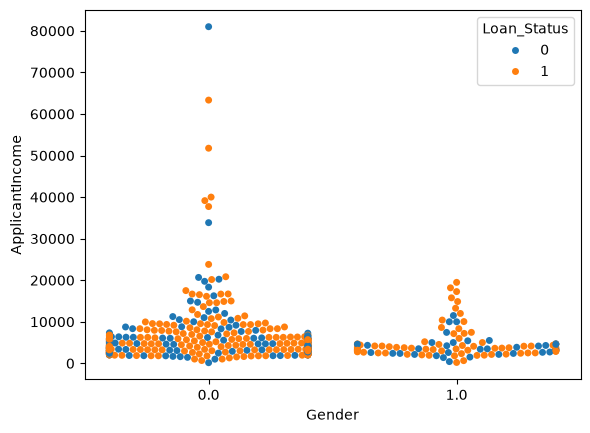

In [28]:
sns.swarmplot(
    x="Gender",
    y="ApplicantIncome",
    hue="Loan_Status",
    data=data
)

plt.show()

In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
print(y.value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64
